# 04. Análise de Resíduos, Cross-Validation e Robustez por Segmento

Este notebook cobre as etapas 8 e 9 do case. Olhamos os resíduos do melhor modelo no teste, já que uma métrica agregada sozinha pode esconder padrões de erro. Rodamos uma validação cruzada K-Fold em todos os modelos para medir a estabilidade de cada um. E checamos se o erro é uniforme entre segmentos de negócio, não só na média agregada.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import data_prep, modeling, evaluation, interpretability, visualization

visualization.set_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

In [2]:
df = pd.read_csv(PROCESSED_DIR / "dataset_limpo.csv")
target = data_prep.TARGET
X_train, X_test, y_train, y_test = data_prep.load_processed_split()

models = modeling.get_models()
comparison = pd.read_csv(PROCESSED_DIR / "model_comparison.csv")

_, preds_test = evaluation.evaluate_models(models, X_train, y_train, X_test, y_test)
comparison

,modelo,MAE,RMSE,R2,MAPE,ganho_RMSE_vs_baseline
0,GradientBoosting,283.708130,352.559216,0.540296,0.130046,0.322594
1,Ridge,288.399634,357.656691,0.526907,0.130949,0.312799
2,Linear,288.415606,357.686779,0.526827,0.130951,0.312741
3,RandomForest,287.368908,362.780748,0.513254,0.132757,0.302954
4,XGBoost,317.876756,394.697322,0.423841,0.143301,0.241630
5,DecisionTree,352.062169,440.616263,0.281982,0.162488,0.153401
6,Baseline (média),418.923653,520.454484,-0.001797,0.198052,0.000000


## 8. Analisar os resíduos

Modelo analisado (melhor no teste, só para diagnóstico exploratório de resíduos): GradientBoosting


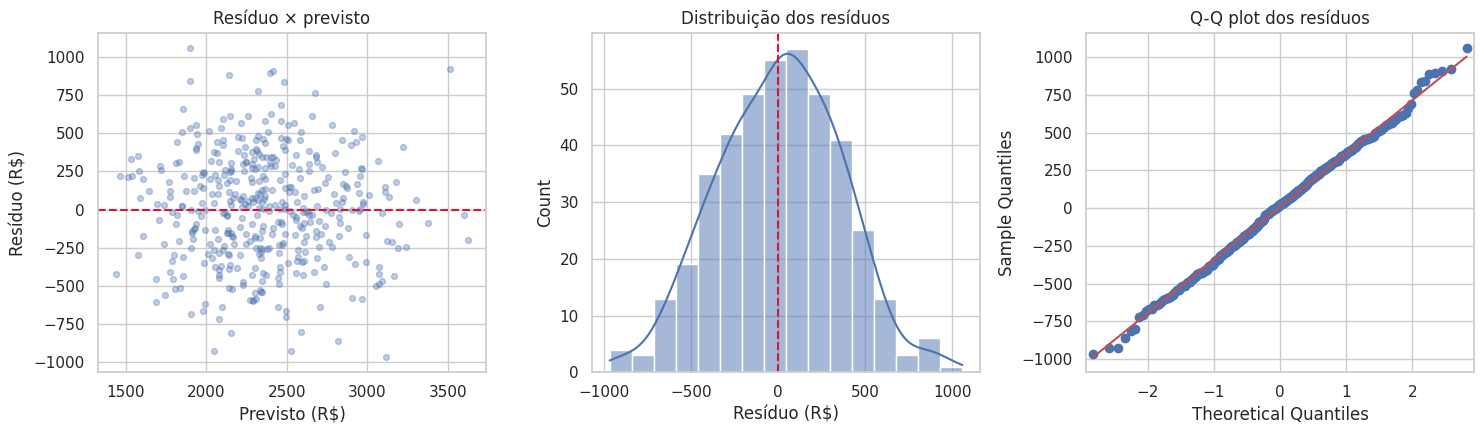

Resíduo médio: 9.31 (deveria ser ~0 se não houver viés sistemático)
Assimetria dos resíduos: -0.030
Jarque-Bera p-valor: 0.8324


In [3]:
best_test_model = comparison[comparison["modelo"] != "Baseline (média)"].sort_values("RMSE").iloc[0]["modelo"]
fitted = preds_test[best_test_model]
resid = y_test.values - fitted
print(f"Modelo analisado (melhor no teste, só para diagnóstico exploratório de resíduos): {best_test_model}")

visualization.plot_residual_diagnostics(fitted, resid)
plt.show()

print(f"Resíduo médio: {resid.mean():.2f} (deveria ser ~0 se não houver viés sistemático)")
print(f"Assimetria dos resíduos: {stats.skew(resid):.3f}")
print(f"Jarque-Bera p-valor: {stats.jarque_bera(resid).pvalue:.4f}")

In [4]:
bp = evaluation.breusch_pagan_test(resid, X_test)
print(f"Breusch-Pagan: estatística LM = {bp['lm_stat']:.2f}, p-valor = {bp['lm_pvalue']:.3f}")
print("p-valor > 0.05 -> sem evidência forte de heterocedasticidade" if bp["lm_pvalue"] > 0.05
      else "p-valor <= 0.05 -> evidência de heterocedasticidade (variância do erro não constante)")

Breusch-Pagan: estatística LM = 6.60, p-valor = 0.678
p-valor > 0.05 -> sem evidência forte de heterocedasticidade


* A nuvem de resíduo contra previsto não mostra funil nem curvatura evidente. O resíduo médio fica perto de zero, o que indica que não há viés sistemático, e o Q-Q plot fica próximo da reta de referência.
* Não há sinal de que o modelo erre sistematicamente mais em alguma faixa de gasto, o que é um bom indício de robustez. Vale lembrar, porém, que "sem evidência forte" (um p-valor perto do limiar de 0,05) não é o mesmo que "prova de ausência" de heterocedasticidade. É uma leitura cautelosa, não uma certeza.

## 9. Cross-validation

Um único split de treino e teste pode parecer melhor ou pior do que realmente é, só por sorte da divisão. Por isso rodamos uma validação cruzada K-Fold (k=5) para todos os modelos, medindo a média e o desvio-padrão de MAE/RMSE/R² entre os folds. Esse resultado, e não o RMSE de um único teste, é o que orienta a escolha do modelo final no notebook 05.

In [5]:
cv_df, cv_raw = evaluation.cross_validate_models(models, X_train, y_train)
cv_df.to_csv(PROCESSED_DIR / "cv_results.csv", index=False)
cv_df

,modelo,MAE_cv_media,MAE_cv_std,RMSE_cv_media,RMSE_cv_std,R2_cv_media,R2_cv_std
0,Ridge,286.588981,10.887599,363.730245,16.039247,0.577880,0.016967
1,Linear,286.594313,10.878159,363.732162,16.026899,0.577874,0.016981
2,GradientBoosting,298.356544,12.649975,376.590910,16.541578,0.547605,0.014073
3,RandomForest,306.669730,11.936137,387.894511,16.704744,0.519872,0.018383
4,XGBoost,330.195283,13.727453,414.918215,18.895414,0.449725,0.039247
5,DecisionTree,369.679236,15.868106,470.206177,22.543112,0.295061,0.019937


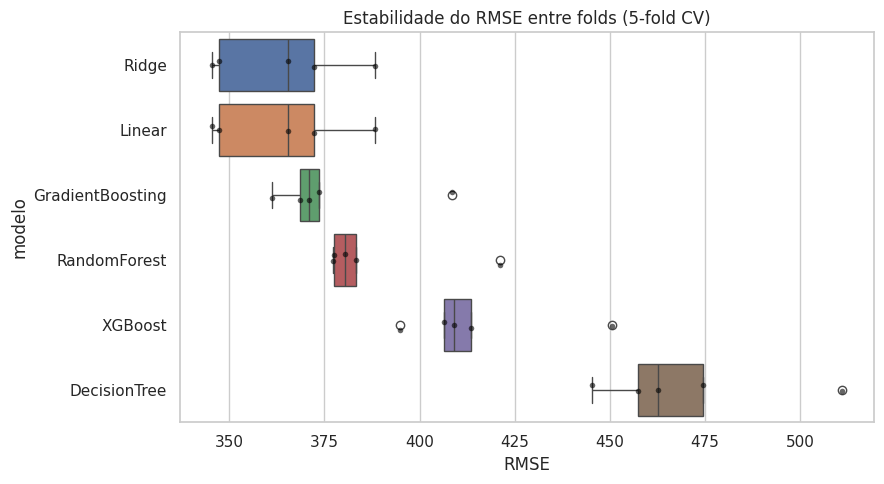

In [6]:
fold_rmse = pd.DataFrame({name: -cv_raw[name]["test_neg_root_mean_squared_error"] for name in models})
fold_rmse_long = fold_rmse.melt(var_name="modelo", value_name="RMSE")
order = cv_df["modelo"].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=fold_rmse_long, x="RMSE", y="modelo", order=order, palette="deep", ax=ax)
sns.stripplot(data=fold_rmse_long, x="RMSE", y="modelo", order=order, color="black", size=4, alpha=0.6, ax=ax)
ax.set_title("Estabilidade do RMSE entre folds (5-fold CV)")
plt.tight_layout()
plt.show()

* A cross-validation confirma o holdout: os modelos lineares têm os menores RMSE médios.
* Gradient Boosting fica logo atrás.
* XGBoost e Random Forest são mais estáveis entre os folds, mas têm RMSE maior.
* Menor RMSE e maior estabilidade não necessariamente andam juntos.

## 10. Robustez por segmento de negócio

Uma métrica agregada pode esconder diferenças de desempenho entre grupos de clientes. Aqui olhamos o erro do melhor modelo do holdout (só para ilustrar, já que a análise definitiva do modelo final está no notebook 06) separado por faixa de renda, para checar se a qualidade da previsão é uniforme entre clientes de renda baixa, média e alta.

In [7]:
seg_renda = evaluation.segment_metrics(y_test, fitted, X_test["renda"], label="faixa_renda")
seg_renda

,faixa_renda,n,MAE,RMSE,MAPE
0,"(1474.738, 4201.634]",104,285.876394,367.130060,0.140668
1,"(4201.634, 5784.094]",104,271.153408,338.484814,0.131416
2,"(5784.094, 7606.146]",103,309.769701,364.094077,0.143344
3,"(7606.146, 23468.803]",104,268.283608,339.632952,0.104884


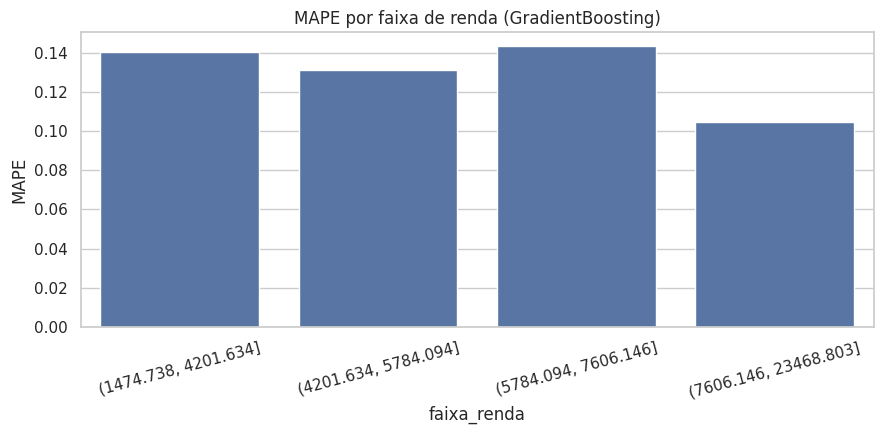

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=seg_renda, x="faixa_renda", y="MAPE", ax=ax, color="#4C72B0")
ax.set_title(f"MAPE por faixa de renda ({best_test_model})")
ax.set_ylabel("MAPE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

O erro relativo (MAPE) tende a ser menor para clientes de renda mais alta e um pouco maior nas faixas de renda mais baixa. Ou seja, o modelo não é perfeitamente uniforme entre segmentos, mas a diferença não é dramática. Isso é uma informação relevante para o negócio: decisões de priorização baseadas neste modelo devem levar em conta que a margem de erro relativa é um pouco maior para clientes de renda mais baixa, algo que a métrica agregada de MAE/RMSE sozinha não mostrava.